# Route Optimisation with ACO

Demonstrates PreferendusACO on a directed grid graph with two objectives:

| Objective | Direction | Meaning |
|-----------|-----------|--------|
| 1_distance | minimise | total route length (m) |
| 2_slope    | minimise | total absolute slope |

Preference-curve bounds are derived automatically via two Dijkstra calibration runs.

## 1. Imports

In [2]:
import sys
import os
import heapq
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import PchipInterpolator

_here = Path(os.getcwd())
_repo_root = _here if (_here / 'examples').exists() else _here.parent

_examples_path = str(_repo_root / 'examples')
if _examples_path not in sys.path:
    sys.path.insert(0, _examples_path)
from utils.route_problem import build_grid, generate_slopes_distances, plot_route

_src_path = str(_repo_root / 'src')
if _src_path not in sys.path:
    sys.path.insert(0, _src_path)
from preferendus.optimization.aco.modo import PreferendusACO

import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
%matplotlib inline

## 2. Build the graph

11x4 intermediate nodes, step 10 m, plus start (0,30) and goal (120,30).
Directed edges connect each node only to the next column.
Edge slopes ~ N(0, 0.3) clipped to [-1, 1].

In [3]:
grid_coords, X, Y, idx_start, idx_goal, edges = build_grid()
edge_slopes, edge_distances = generate_slopes_distances(grid_coords, edges)
edge_abs_slopes = {e: abs(v) for e, v in edge_slopes.items()}

print(f'Nodes        : {len(grid_coords)}')
print(f'Edges        : {len(edge_slopes)}')
print(f'Slope range  : [{min(edge_slopes.values()):.3f}, {max(edge_slopes.values()):.3f}]')
print(f'|Slope| range: [{min(edge_abs_slopes.values()):.3f}, {max(edge_abs_slopes.values()):.3f}]')

Nodes        : 46
Edges        : 168
Slope range  : [-0.640, 0.874]
|Slope| range: [0.004, 0.874]


## 3. Calibrate preference-curve bounds

| Run | Minimises | Gives |
|-----|-----------|-------|
| Pure slope    | sum(|slope|)  | min_abs_slope -> pref 100; that path dist -> dist worst |
| Pure distance | sum(distance) | min_dist -> pref 100; that path |slope| -> slope worst |

In [4]:
def _dijkstra(attr, edges, start, goal):
    prev, d, heap = {}, {start: 0.0}, [(0.0, start)]
    while heap:
        cost, node = heapq.heappop(heap)
        if node == goal: break
        if cost > d.get(node, float('inf')): continue
        for nb in edges[node]:
            nc = cost + attr.get((node, nb), 0)
            if nc < d.get(nb, float('inf')):
                d[nb] = nc; prev[nb] = node; heapq.heappush(heap, (nc, nb))
    path, node = [], goal
    while node in prev: path.append(node); node = prev[node]
    path.append(start); path.reverse()
    return d[goal], path

def _path_total(path, attr):
    return sum(attr.get((path[i], path[i+1]), 0) for i in range(len(path)-1))

min_abs_slope, pure_slope_path = _dijkstra(edge_abs_slopes, edges, idx_start, idx_goal)
pure_slope_path_dist = _path_total(pure_slope_path, edge_distances)
min_dist, pure_dist_path = _dijkstra(edge_distances, edges, idx_start, idx_goal)
pure_dist_path_abs_slope = _path_total(pure_dist_path, edge_abs_slopes)

slope_pref_best  = min_abs_slope
slope_pref_worst = pure_dist_path_abs_slope * 1.2
dist_pref_best   = min_dist
dist_pref_worst  = pure_slope_path_dist * 1.2

print(f'Pure-slope path : |slope| = {min_abs_slope:.3f},  dist = {pure_slope_path_dist:.2f} m')
print(f'Pure-dist  path : |slope| = {pure_dist_path_abs_slope:.3f},  dist = {min_dist:.2f} m')
print(f'Slope pref curve: [{slope_pref_best:.3f} -> 100,  {slope_pref_worst:.3f} -> 0]')
print(f'Dist  pref curve: [{dist_pref_best:.2f}  -> 100,  {dist_pref_worst:.2f}  -> 0]')

Pure-slope path : |slope| = 0.978,  dist = 181.93 m
Pure-dist  path : |slope| = 3.650,  dist = 120.00 m
Slope pref curve: [0.978 -> 100,  4.380 -> 0]
Dist  pref curve: [120.00  -> 100,  218.32  -> 0]


## 4. Define preference functions

In [5]:
x_points_distance = [dist_pref_best,  dist_pref_worst]
p_points_distance = [100, 0]
x_points_slope    = [slope_pref_best, slope_pref_worst]
p_points_slope    = [100, 0]

def _pref_dist(d):
    return float(np.clip(PchipInterpolator(x_points_distance, p_points_distance)(d), 0, 100))

def _pref_slope(s):
    return float(np.clip(PchipInterpolator(x_points_slope, p_points_slope)(s), 0, 100))

stakeholder_preferences = {
    1: {'1_distance': _pref_dist, '2_slope': _pref_slope},
}
objective_weights = {
    1: {'1_distance': 0.50, '2_slope': 0.50},
}

### Preference functions (calibrated bounds)

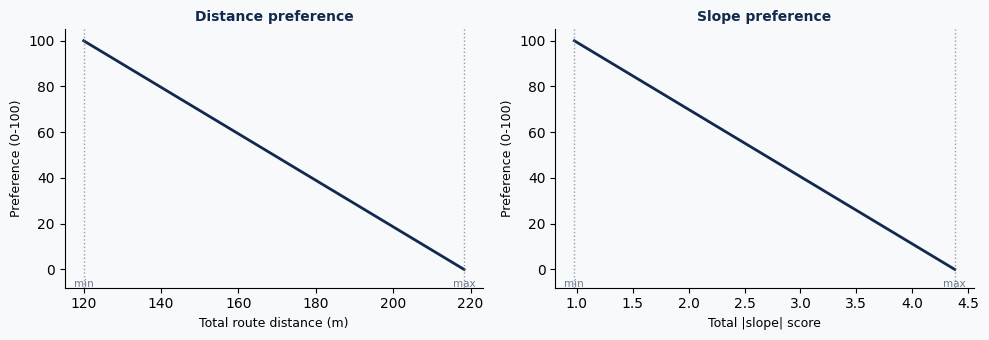

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
configs = [
    (x_points_distance, p_points_distance, 'Total route distance (m)', 'Distance preference'),
    (x_points_slope,    p_points_slope,    'Total |slope| score',      'Slope preference'),
]
for ax, (xp, pp, xlabel, title) in zip(axes, configs):
    interp = PchipInterpolator(xp, pp)
    xs = np.linspace(xp[0], xp[-1], 200)
    ax.plot(xs, interp(xs), color='#11294e', linewidth=2)
    for x_bound, label in [(xp[0], 'min'), (xp[-1], 'max')]:
        ax.axvline(x_bound, color='#6b7a8d', linestyle=':', linewidth=1, alpha=0.7)
        ax.text(x_bound, -4, label, ha='center', va='top', fontsize=7.5, color='#6b7a8d')
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Preference (0-100)', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold', color='#11294e')
    ax.set_ylim(-8, 105)
    ax.set_facecolor('#f7f9fb')
    ax.spines[['top', 'right']].set_visible(False)
fig.patch.set_facecolor('#f7f9fb')
fig.tight_layout()
plt.show()

## 5. Configure and run ACO

| Parameter | Value | Meaning |
|-----------|-------|---------|
| num_ants | 200 | paths per iteration |
| num_iterations | 20 | generations |
| alpha | 1.0 | pheromone influence |
| beta | 0.75 | heuristic influence |
| rho | 0.05 | evaporation rate |
| elite_size | 50 | hall-of-fame size |

In [7]:
optimization_options = {
    'num_ants': 200, 'num_iterations': 20,
    'alpha': 1.0, 'beta': 0.75, 'rho': 0.05,
    'elite_size': 50, 'seed': 42,
}

graph = {
    'edges': edges, 'idx_start': idx_start, 'idx_goal': idx_goal,
    'edge_scores': edge_abs_slopes,
    'edge_distances': edge_distances,
}

@PreferendusACO(
    preference_functions=stakeholder_preferences,
    stakeholder_weights=[1.0],
    objective_weights=objective_weights,
    graph=graph,
    optimization_options=optimization_options,
)
def evaluate_route(path):
    """Return total distance and total absolute slope for a route."""
    total_distance  = sum(edge_distances[(path[i], path[i+1])] for i in range(len(path)-1))
    total_abs_slope = sum(abs(edge_slopes[(path[i], path[i+1])]) for i in range(len(path)-1))
    return None, None, total_distance, total_abs_slope

In [8]:
result = evaluate_route()

best_path      = result['x_opt']
score        = result['utility']
best_dist      = sum(edge_distances[(best_path[i], best_path[i+1])] for i in range(len(best_path)-1))
best_abs_slope = sum(abs(edge_slopes[(best_path[i], best_path[i+1])]) for i in range(len(best_path)-1))

print(f'Total distance      : {best_dist:.2f} m')
print(f'Total |slope| score : {best_abs_slope:.3f}')
print(f'Preference          : {round(score, 4)}')

Iteration 1/20  a_fine=100.0  valid_ants=200
Iteration 2/20  a_fine=100.0  valid_ants=200
Iteration 3/20  a_fine=100.0  valid_ants=200
Iteration 4/20  a_fine=100.0  valid_ants=200
Iteration 5/20  a_fine=100.0  valid_ants=200
Iteration 6/20  a_fine=100.0  valid_ants=200
Iteration 7/20  a_fine=100.0  valid_ants=200
Iteration 8/20  a_fine=100.0  valid_ants=200
Iteration 9/20  a_fine=100.0  valid_ants=200
Iteration 10/20  a_fine=100.0  valid_ants=200
Iteration 11/20  a_fine=100.0  valid_ants=200
Iteration 12/20  a_fine=100.0  valid_ants=200
Iteration 13/20  a_fine=100.0  valid_ants=200
Iteration 14/20  a_fine=100.0  valid_ants=200
Iteration 15/20  a_fine=100.0  valid_ants=200
Iteration 16/20  a_fine=100.0  valid_ants=200
Iteration 17/20  a_fine=100.0  valid_ants=200
Iteration 18/20  a_fine=100.0  valid_ants=200
Iteration 19/20  a_fine=100.0  valid_ants=200
Iteration 20/20  a_fine=100.0  valid_ants=200
Final objective values : {'1_distance': 153.1370849898476, '2_slope': 1.0966839102257093}

## 6. Results

### 6a. Convergence

This should naturally show 100 on each iteration.

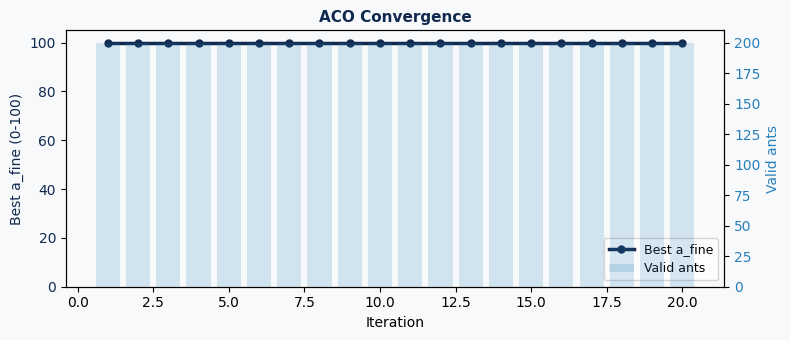

In [9]:
history = result['history']
iters = [h['iteration'] for h in history]
afines = [h['best_afine'] for h in history]
n_paths = [h['num_valid_paths'] for h in history]

fig, ax1 = plt.subplots(figsize=(8, 3.5))
ax1.plot(iters, afines, color='#11294e', linewidth=2.5, marker='o', markersize=5, label='Best a_fine')
ax1.set_xlabel('Iteration', fontsize=10)
ax1.set_ylabel('Best a_fine (0-100)', fontsize=10, color='#11294e')
ax1.tick_params(axis='y', labelcolor='#11294e')
ax1.set_ylim(0, 105)
ax2 = ax1.twinx()
ax2.bar(iters, n_paths, alpha=0.18, color='#2980b9', label='Valid ants')
ax2.set_ylabel('Valid ants', fontsize=10, color='#2980b9')
ax2.tick_params(axis='y', labelcolor='#2980b9')
l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, fontsize=9, loc='lower right')
ax1.set_title('ACO Convergence', fontsize=11, fontweight='bold', color='#11294e')
ax1.set_facecolor('#f7f9fb')
fig.patch.set_facecolor('#f7f9fb')
fig.tight_layout()
plt.show()

### 6b. Best route

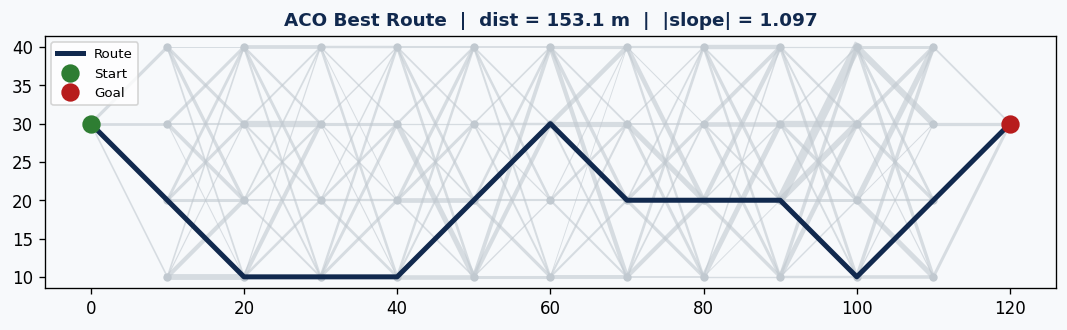

In [10]:
import base64
from IPython.display import Image, display

png_b64 = plot_route(
    grid_coords, edge_slopes, X, Y, best_path,
    title=f'ACO Best Route  |  dist = {best_dist:.1f} m  |  |slope| = {best_abs_slope:.3f}'
)
display(Image(data=base64.b64decode(png_b64)))

### 6c. Preference scores — three strategies compared

| Colour | Path | Strategy |
|--------|------|----------|
| Green | min-slope path | Dijkstra on |slope| |
| Blue  | min-distance path | Dijkstra on distance |
| Red   | ACO result | weighted multi-objective |

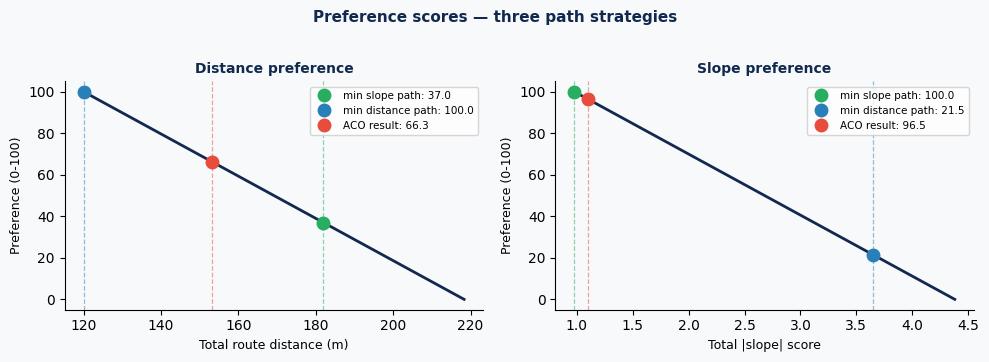

Min-slope path    : dist=181.9 m, |slope|=0.978
Min-distance path : dist=120.0 m, |slope|=3.650
ACO result        : dist=153.1 m, |slope|=1.097
Preference        : 81.4013


In [12]:
pts_dist = [
    (pure_slope_path_dist,     _pref_dist(pure_slope_path_dist),     '#27ae60', 'min slope path'),
    (min_dist,                 _pref_dist(min_dist),                 '#2980b9', 'min distance path'),
    (best_dist,                _pref_dist(best_dist),                '#e74c3c', 'ACO result'),
]
pts_slope = [
    (min_abs_slope,            _pref_slope(min_abs_slope),            '#27ae60', 'min slope path'),
    (pure_dist_path_abs_slope, _pref_slope(pure_dist_path_abs_slope), '#2980b9', 'min distance path'),
    (best_abs_slope,           _pref_slope(best_abs_slope),           '#e74c3c', 'ACO result'),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
pref_data = [
    (axes[0], x_points_distance, p_points_distance, pts_dist,  'Total route distance (m)', 'Distance preference'),
    (axes[1], x_points_slope,    p_points_slope,    pts_slope, 'Total |slope| score',      'Slope preference'),
]
for ax, xp, pp, pts, xlabel, title in pref_data:
    interp = PchipInterpolator(xp, pp)
    xs = np.linspace(xp[0], xp[-1], 200)
    ax.plot(xs, interp(xs), color='#11294e', linewidth=2, zorder=1)
    for x_val, y_val, col, label in pts:
        ax.plot(x_val, y_val, 'o', color=col, markersize=9, zorder=5, label=f'{label}: {y_val:.1f}')
        ax.axvline(x_val, color=col, linestyle='--', linewidth=0.9, alpha=0.5, zorder=2)
    ax.legend(fontsize=7.5, loc='upper right')
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Preference (0-100)', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold', color='#11294e')
    ax.set_ylim(-5, 105)
    ax.set_facecolor('#f7f9fb')
    ax.spines[['top', 'right']].set_visible(False)
fig.patch.set_facecolor('#f7f9fb')
fig.suptitle('Preference scores — three path strategies', fontsize=11, fontweight='bold', color='#11294e', y=1.02)
fig.tight_layout()
plt.show()

print(f'Min-slope path    : dist={pure_slope_path_dist:.1f} m, |slope|={min_abs_slope:.3f}')
print(f'Min-distance path : dist={min_dist:.1f} m, |slope|={pure_dist_path_abs_slope:.3f}')
print(f'ACO result        : dist={best_dist:.1f} m, |slope|={best_abs_slope:.3f}')
print(f'Preference        : {round(score, 4)}')